<a href="https://colab.research.google.com/github/OPCIO0568/2026-1_CV/blob/main/HW%232-5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

원본 이미지


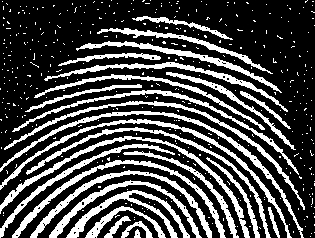

이진화 결과


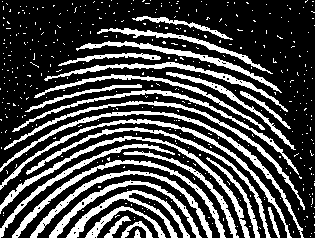

kernel =
 [[1 1 1]
 [1 1 1]
 [1 1 1]]
침식 (Erosion)


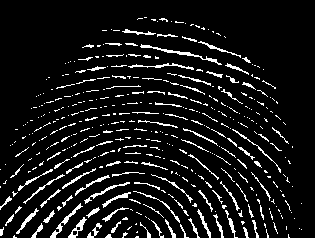

팽창 (Dilation)


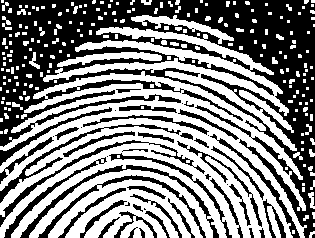

열기 (Opening)


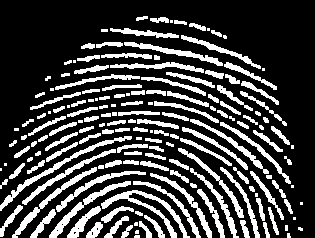

닫기 (Closing)


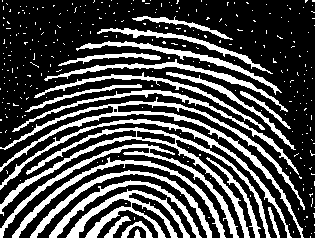

열기 후 닫기 (Opening -> Closing)


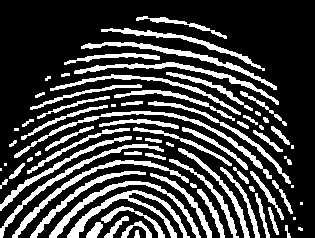

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

# grayscale로 읽기
img = cv2.imread('/content/finger.jpg', cv2.IMREAD_GRAYSCALE)

print("원본 이미지")
cv2_imshow(img)

# -------------------------------
# 2) 이진화
# -------------------------------
# 지문 예시처럼 morphology는 보통 binary image에 적용
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

print("이진화 결과")
cv2_imshow(binary)

# -------------------------------
# 3) 구조 요소(structuring element)
# -------------------------------
kernel = np.ones((3, 3), np.uint8)
print("kernel =\n", kernel)

# -------------------------------
# 4) 각각의 연산
# -------------------------------
# 침식 (Erosion)
erosion = cv2.erode(binary, kernel, iterations=1)

# 팽창 (Dilation)
dilation = cv2.dilate(binary, kernel, iterations=1)

# 열기 (Opening) = 침식 후 팽창
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 닫기 (Closing) = 팽창 후 침식
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# 열기 후 닫기
opening_then_closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

# -------------------------------
# 5) 결과 출력
# -------------------------------
print("침식 (Erosion)")
cv2_imshow(erosion)

print("팽창 (Dilation)")
cv2_imshow(dilation)

print("열기 (Opening)")
cv2_imshow(opening)

print("닫기 (Closing)")
cv2_imshow(closing)

print("열기 후 닫기 (Opening -> Closing)")
cv2_imshow(opening_then_closing)

#침식은 노이즈를 제거하였지만 선도 가늘어졌으며 opening이 지문 손상이 가장 적으며 노이즈 제거가 좋았음
#지문을 잘 보이게 하지만 노이즈도 함께 커졌으며 closing는 노이즈를 완전 제거하지 못하였음
#opening후 closing이 노이즈 제거와 지문 손상이 제일 적었음